In [1]:
import datetime as dt
import pandas as pd
import numpy as np
import seaborn as sns
import math
import matplotlib.pyplot as plt
from matplotlib.ticker import AutoMinorLocator, MultipleLocator
from importFunctions_TUOL import channelCapacityAdj_Tuol, getSpringStartTiming, WET_MAG_ADJ,SP_MAG_ADJ,DS_MAG_ADJ, PEAK_MAG, FA_MAG_ADJ
from FFM_GeneralFunctions import getWY, wyToDate, dateToWY, getSPStart

This is just a reminder to double check that the spring pulse is behaving.


In [2]:
def cfs_to_cms(flow_cfs):
    return 0.02831683199881 * flow_cfs

def _collapse_row_gap(axs, row_top=0, row_bottom=1, cols=(0, 1), eps=0.0):
    """
    Force the bottom of row_top axes to touch the top of row_bottom axes.
    eps can be slightly negative (e.g., -0.002) to overlap by a hair if you want.
    """
    for c in cols:
        ax_top = axs[row_top, c]
        ax_bot = axs[row_bottom, c]

        pos_top = ax_top.get_position()
        pos_bot = ax_bot.get_position()

        gap = pos_top.y0 - pos_bot.y1  # >0 means there's whitespace between rows
        if gap > 0:
            # Expand the TOP axes downward to eliminate the gap
            new_y0 = pos_top.y0 - gap + eps
            new_h  = pos_top.height + gap - eps
            ax_top.set_position([pos_top.x0, new_y0, pos_top.width, new_h])

def plot_fri_grid(
    df,
    metrics,
    *,
    x_col="ann_vol_percentile",
    nrows=2,
    ncols=2,
    figsize=(11, 8),
    xpad_frac=0,
    channel_capacity=None,
    channel_label="Channel capacity",
    scatter_kws=None,
    line_kws=None,
    suptitle=None,
    savepath=None,
    # --- NEW options
    subtitle_fs_delta=-1,
    convert_to_cms=False,
    rightcol_y_on_right=True,
    grid_alpha_major=0.18,
    grid_alpha_minor=0.10,
    grid_lw_major=0.7,
    grid_lw_minor=0.5,
    sharex=True,
    legend_ncol=3,
    # --- NEW: hard layout override
    force_no_row_gap=True,
    force_no_row_gap_eps=-5,   # set to -0.002 if you want a tiny overlap
):
    if scatter_kws is None:
        scatter_kws = dict(s=12, alpha=0.6, c='black', edgecolors="none", rasterized=True)
    if line_kws is None:
        line_kws = dict(lw=2.0, c='#408EC6')
    fri_text_c ="#2F6F9D"
    fig, axs = plt.subplots(
        nrows=nrows, ncols=ncols, figsize=figsize,
        sharex=sharex, tight_layout=False
    )
    axs = np.array(axs)

    x_raw = df[x_col].to_numpy()
    x = x_raw / 100.0 if np.nanmax(x_raw) > 1.5 else x_raw

    base_title_fs = plt.rcParams.get("axes.titlesize", plt.rcParams.get("font.size", 10))
    try:
        subtitle_fs = float(base_title_fs) + float(subtitle_fs_delta)
    except Exception:
        subtitle_fs = float(plt.rcParams.get("font.size", 10)) + float(subtitle_fs_delta)

    y_mult = 0.02831683199881 if convert_to_cms else 1.0
    channel_capacity_plot = (channel_capacity * y_mult) if (channel_capacity is not None) else None

    for i, spec in enumerate(metrics):
        r, c = divmod(i, ncols)
        ax = axs[r, c]

        ycol = spec["col"]
        y = df[ycol].to_numpy() * y_mult

        ax.scatter(x, y, label="Natural metric data", **scatter_kws)

        MIN = spec["min"] * y_mult
        MAX = spec["max"] * y_mult

        m, b = np.polyfit([MIN, MAX], [0.10, 0.90], 1)
        x_fri = np.linspace(0.1, 0.9, 200)
        y_fri = (x_fri - b) / m
        ax.plot(x_fri, y_fri, label="FRI function", **line_kws)

        ax.axvline(0.1, color="r", linestyle=(0, (5, 6)), lw=1, label="FRI 10 / 90")
        ax.axvline(0.9, color="r", linestyle=(0, (5, 6)), lw=1)

        ax.set_xlim(0.0 - xpad_frac, 1.0 + xpad_frac)

        subtitle = spec.get("subtitle", ycol)
        ax.text(0.5, 0.98, subtitle, transform=ax.transAxes,
                ha="center", va="top", fontsize=subtitle_fs)

        ylabel = spec.get("ylabel", ycol)
        if convert_to_cms:
            ylabel = ylabel.replace("(cfs)", "(cms)").replace("cfs", "cms")
        ax.set_ylabel(ylabel)

        if spec.get("ylim") is not None:
            ymin, ymax = spec["ylim"]
            ymin *= y_mult
            ymax *= y_mult
        else:
            data_ymax = np.nanmax(y)
            data_ymin = np.nanmin(y)

            ymin = spec.get("ymin", min(0.0, data_ymin))
            ymax_auto = max(data_ymax, MAX)
            ymax = spec.get("ymax", ymax_auto)

            if "ymin" in spec:
                ymin *= y_mult
            if "ymax" in spec:
                ymax *= y_mult
            if "ymin" not in spec:
                ymin = min(0.0, data_ymin)
            if "ymax" not in spec:
                ymax = ymax_auto

            pad = 0.10 * (ymax - ymin) if ymax > ymin else 1.0
            ymax = ymax + pad

        ax.set_ylim(ymin, ymax)

        if channel_capacity_plot is not None and ax.get_ylim()[1] > channel_capacity_plot:
            ax.axhline(channel_capacity_plot, color="k", linestyle="--", lw=1.2, alpha=0.75)
            ax.text(0.02, channel_capacity_plot, channel_label,
                    ha="left", va="bottom", fontsize=9, color="k", alpha=0.85,
                    transform=ax.get_yaxis_transform())

        ax.yaxis.set_minor_locator(AutoMinorLocator(2))
        ax.set_xticks(np.arange(0.0, 1.01 ,10))
        ax.xaxis.set_minor_locator(AutoMinorLocator(2))
        #ax.xaxis.set_major_locator(MultipleLocator(0.1))
        ax.xaxis.set_major_locator(MultipleLocator(0.2))
        
        ax.grid(True, which="major", axis="both", alpha=grid_alpha_major, linewidth=grid_lw_major)
        ax.grid(True, which="minor", axis="both", alpha=grid_alpha_minor, linewidth=grid_lw_minor)

        # Top FRI axis ONLY on top row
    
        secax = ax.secondary_xaxis("top", functions=(lambda p: p * 100, lambda P: P / 100), color=fri_text_c)
        secax.set_xticks(np.arange(0, 101, 10))
        secax.xaxis.set_minor_locator(AutoMinorLocator(2))
        if r==0: secax.set_xlabel("Flow Regime Index (FRI)", color=fri_text_c, fontweight=500)
        secax.tick_params(top=True, labeltop=True, color='k')
        if r>0: 
            secax.tick_params(labeltop=False)
            secax.set_ylabel(None)

        # Bottom axis only on bottom row
        if r == nrows - 1:
            ax.set_xlabel("Water year percentile", fontweight=500)
            ax.tick_params(bottom=True, labelbottom=True)
        else:
            ax.set_xlabel("")
            ax.tick_params(bottom=False, labelbottom=False)

        if rightcol_y_on_right and c == ncols - 1:
            ax.yaxis.set_label_position("right")
            ax.yaxis.tick_right()
            ax.tick_params(axis="y", which="both", left=False, right=True)
            ax.spines["right"].set_visible(True)
            ax.spines["left"].set_visible(False)

        sns.despine(ax=ax, top=False, right=False)#not (rightcol_y_on_right and c == ncols - 1))
        if r==1:
            ax.spines["top"].set_visible(False)
            secax.spines["top"].set_visible(False)
    # Disable unused axes
    for j in range(len(metrics), nrows * ncols):
        r, c = divmod(j, ncols)
        axs[r, c].axis("off")

    # # Optional spine cleanup where rows touch (visual polish)
    # for ax in axs[0, :]:
    #     ax.spines["bottom"].set_visible(False)
    # for ax in axs[1, :]:
    #     ax.spines["top"].set_visible(False)

    # Base spacing
    fig.subplots_adjust(hspace=0.0, wspace=0.10, bottom=0.16)

    # --- THE KEY FIX: force rows to touch
    if force_no_row_gap and nrows >= 2:
        _collapse_row_gap(axs, row_top=0, row_bottom=1, cols=range(ncols), eps=force_no_row_gap_eps)

    if suptitle:
        fig.suptitle(suptitle, y=0.98, fontsize=14)

    handles, labels = axs.flat[0].get_legend_handles_labels()
    fig.legend(handles, labels, loc="upper center",
               bbox_to_anchor=(0.5, 0.005), ncol=legend_ncol, framealpha=1)

    if savepath:
        fig.savefig(savepath, transparent=True, dpi=300, bbox_inches="tight")

    return fig, axs


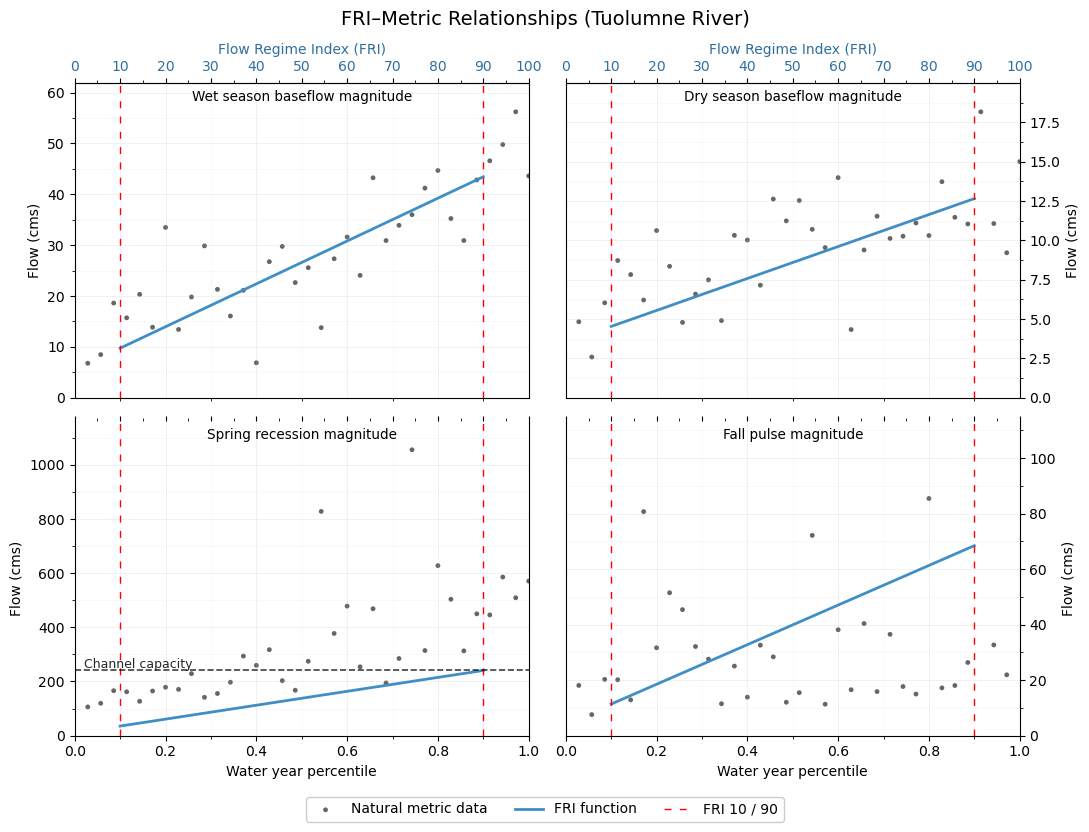

In [3]:
path = "/Users/lindsaybean/Library/Mobile Documents/com~apple~CloudDocs/Documents/UC Davis/GSR/Functional_Flows/Models/Tuolumne_Model_TLG/InputData/sjriver_ffm_fish-main_lm/output/ffc_TLG/2823750_ffc_results.csv"

ffm_df = pd.read_csv(path)

metrics = [
    {"col": "Wet_BFL_Mag_10", "min": WET_MAG_ADJ[10],  "max": WET_MAG_ADJ[90], "subtitle": "Wet season baseflow magnitude", "ylabel": "Flow (cfs)"},
    {"col": "DS_Mag_50",  "min": DS_MAG_ADJ[10],   "max": DS_MAG_ADJ[90],  "subtitle": "Dry season baseflow magnitude",     "ylabel": "Flow (cfs)"},
    {"col": "SP_Mag",  "min": SP_MAG_ADJ[10],    "max": SP_MAG_ADJ[90],   "subtitle": "Spring recession magnitude",  "ylabel": "Flow (cfs)"},
    {"col": "FA_Mag",  "min": FA_MAG_ADJ[10],   "max": FA_MAG_ADJ[90],  "subtitle": "Fall pulse magnitude",   "ylabel": "Flow (cfs)", "ylim":(0,4000)},
]

fig, axes = plot_fri_grid(
    df=ffm_df,
    metrics=metrics,
    x_col="ann_vol_percentile",
    channel_capacity=8500,
    suptitle="FRI–Metric Relationships (Tuolumne River)",
    savepath="Output/misc_figs/fri_grid_4metrics.png",
    convert_to_cms=True,
    subtitle_fs_delta=-0.25
)

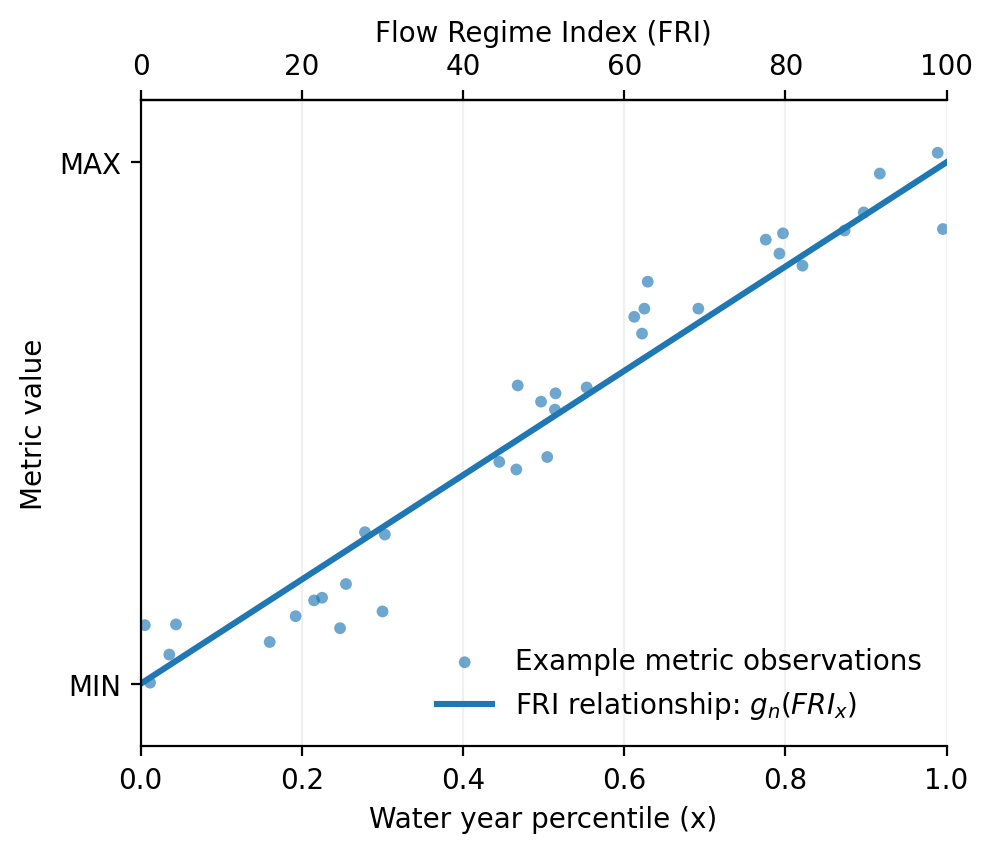

In [4]:
import numpy as np
import matplotlib.pyplot as plt

# ----------------------------
# Dummy conceptual data (sigmoidal)
# ----------------------------
rng = np.random.default_rng(7)

n = 35
x = np.sort(rng.uniform(0, 1, n))  # Annual volume percentile (0–1)

MIN = 20.0
MAX = 120.0

# Sigmoid-shaped underlying relationship scaled to [MIN, MAX]
k = 6.0     # steepness
x0 = 0.5   # midpoint
sig = 1 / (1 + np.exp(-k * (x - x0)))
y_true = MIN + (MAX - MIN) * sig

# Add light noise
y = y_true + rng.normal(0, (MAX - MIN) * 0.06, size=n)

# ----------------------------
# Representative FRI relationship
# (explicitly connects MIN to MAX)
# ----------------------------
x_line = np.array([0.0, 1.0])
y_line = np.array([MIN, MAX])

# ----------------------------
# Plot
# ----------------------------
fig, ax = plt.subplots(figsize=(5.2, 4.2), dpi=200)

ax.scatter(
    x, y,
    s=18,
    alpha=0.65,
    edgecolors="none",
    label="Example metric observations"
)

ax.plot(
    x_line, y_line,
    linewidth=2.2,
    label="FRI relationship: $g_n$($FRI_x$)"
)

ax.set_xlim(0, 1)
ax.set_xlabel("Water year percentile (x)")

# Y-axis: conceptual MIN/MAX labels only
pad = (MAX - MIN) * 0.12
ax.set_ylim(MIN - pad, MAX + pad)
ax.set_yticks([MIN, MAX])
ax.set_yticklabels(["MIN", "MAX"])
ax.set_ylabel("Metric value")

# Secondary top axis: FRI (0–100)
secax = ax.secondary_xaxis(
    "top",
    functions=(lambda p: p * 100, lambda P: P / 100)
)
secax.set_xlabel("Flow Regime Index (FRI)")
secax.set_xticks(np.arange(0, 101, 20))

# Clean styling
ax.spines["right"].set_visible(False)
ax.grid(True, axis='x', alpha=0.18)
ax.legend(frameon=False, loc="lower right")

#fig.savefig("conceptual_fri_relationship_sigmoid_minmax.png", bbox_inches="tight")
plt.show()

/var/folders/f8/f6zv3ljd4llc553h77jw10m40000gq/T/ipykernel_16257/2417381488.py:84: MatplotlibDeprecationWarning: Unable to determine Axes to steal space for Colorbar. Using gca(), but will raise in the future. Either provide the *cax* argument to use as the Axes for the Colorbar, provide the *ax* argument to steal space from it, or add *mappable* to an Axes.
  cbar = fig.colorbar(sm, label='Flow Regime Index (FRI)')


Text(2020-02-25 00:00:00, 228.65841839039075, 'Wet Season Peak')

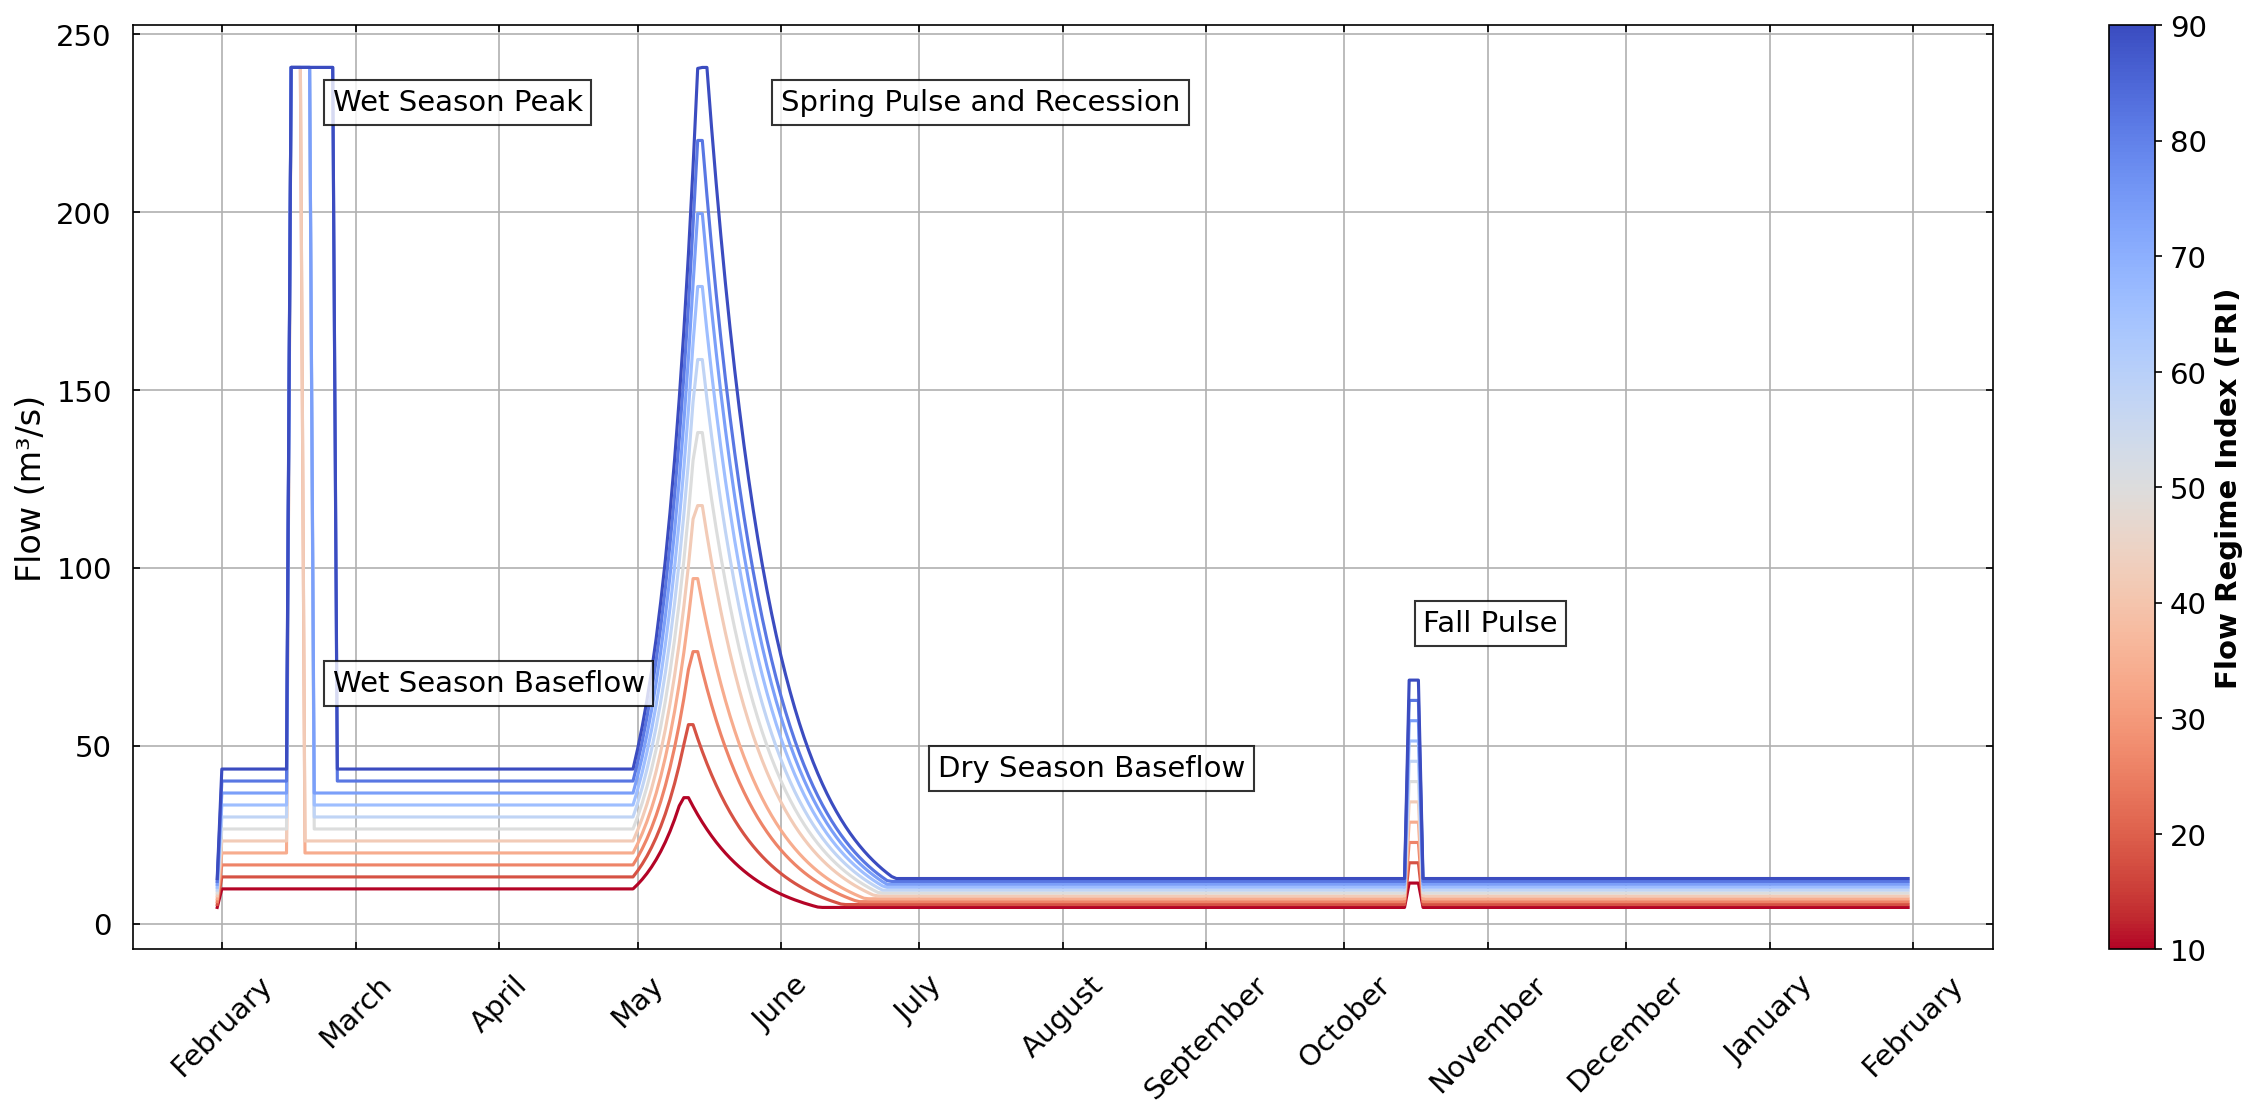

In [8]:
import warnings
warnings.simplefilter(action='ignore', category=FutureWarning)

import numpy as np
import matplotlib.pyplot as plt
import matplotlib.dates as mdates
import datetime as dt
from ffmPerformanceFunctions import inv_performance_Q_WetBFL_cfs,inv_performance_Q_SP_cfs,inv_performance_Q_DS_cfs,inv_performance_Q_FA_cfs 
from FFM_GeneralFunctions import getDailyFlowPeriodDF, dateToWY
import pandas as pd
HIGHLIGHTSCHEDULE=False
peak_mag=8500

df2=pd.DataFrame()

n=11 #Enter number of lines in the patriotic chart
color_arr = plt.cm.coolwarm_r(np.linspace(0,1,n))
z_arr = np.linspace(10,90,n)

dt_wsp = pd.to_datetime('2020-02-25')
dt_wsb = pd.to_datetime('2020-02-25')
dt_spp = pd.to_datetime('2020-06-01')
dt_spr = pd.to_datetime('2020-06-24')
dt_sbf = pd.to_datetime('2020-07-15')
dt_fp = pd.to_datetime('2020-10-18')

fig, ax = plt.subplots(figsize=(20,8),dpi=150)

for i in range(n):
    z = z_arr[i]
    color = color_arr[i]

    if z<34:
        peak_dur = 0
    elif z<50:
        peak_dur = 3
    elif z<75:
        peak_dur = 5
    else:
        peak_dur = 10
    
    Q_WetBFL = inv_performance_Q_WetBFL_cfs(z)
    Q_SP = inv_performance_Q_SP_cfs(z)
    Q_DS = inv_performance_Q_DS_cfs(z)
    Q_FA = inv_performance_Q_FA_cfs(z)

    V_WetPeak = peak_dur * (peak_mag-Q_WetBFL)

    df = getDailyFlowPeriodDF(dt.date(2020,1,31), dt.date(2021,1,31), dateToWY(dt.date(2020,2,1)), dateToWY(dt.date(2020,5,1)), V_WetPeak,Q_WetBFL, Q_SP, Q_DS, Q_FA)
    df['DailyFlow_cfs'] = cfs_to_cms(df['DailyFlow_cfs'])

    df.plot(color=color, ax=ax)
    df2['FFRI_'+str(z)] = df

if HIGHLIGHTSCHEDULE:
    z=10
    if z<34:
        peak_dur = 0
    elif z<50:
        peak_dur = 3
    elif z<75:
        peak_dur = 5
    else:
        peak_dur = 10

    Q_WetBFL1 = inv_performance_Q_WetBFL_cfs(z)
    Q_SP1 = inv_performance_Q_SP_cfs(z)
    Q_DS1 = inv_performance_Q_DS_cfs(z)
    Q_FA1 = inv_performance_Q_FA_cfs(z)

    V_WetPeak = peak_dur * (peak_mag-Q_WetBFL)

    df = getDailyFlowPeriodDF(dt.date(2020,1,31), dt.date(2021,1,31), dateToWY(dt.date(2020,2,1)), dateToWY(dt.date(2020,5,1)), V_WetPeak,Q_WetBFL1, Q_SP1, Q_DS1, Q_FA1)
    df.plot(color='#70AD47', linewidth=3.2, ax=ax, label = 'Flow Schedule with FFRI 60')
    df.plot(color='#FF00FF', linewidth=3.2, ax=ax, label = 'Flow Schedule with FFRI 60')

ax.get_legend().remove()
ax.xaxis.set_major_locator(mdates.MonthLocator())
ax.xaxis.set_major_formatter(mdates.DateFormatter("%B"))
ax.xaxis.set_minor_formatter(mdates.DateFormatter("%B"))
_ = plt.xticks(rotation=45)
sm = plt.cm.ScalarMappable(cmap=plt.cm.coolwarm_r, norm=plt.Normalize(vmin=10, vmax=90))

cbar = fig.colorbar(sm, label='Flow Regime Index (FRI)')
ax.set_ylabel('Flow (m\u00b3/s)',fontsize=16)
cbar.set_label(label='Flow Regime Index (FRI)', size=14, weight='bold')
cbar.ax.tick_params(labelsize=14)

ax.tick_params(axis='both',labelsize=14,direction='in',top=True,right=True, pad = 10)
ax.grid('on')
ax.text(dt_spp,0.95*cfs_to_cms(Q_SP),'Spring Pulse and Recession',fontsize=14,
	bbox=dict(facecolor='w', edgecolor='k',alpha=0.8))
ax.text(dt_sbf-dt.timedelta(days=10),0.95*cfs_to_cms(Q_WetBFL),'Dry Season Baseflow',fontsize=14,
	bbox=dict(facecolor='w', edgecolor='k',alpha=0.8))
ax.text(dt_fp,1.2*cfs_to_cms(Q_FA),'Fall Pulse',fontsize=14,
	bbox=dict(facecolor='w', edgecolor='k',alpha=0.8))
ax.text(dt_wsb,1.5*cfs_to_cms(Q_WetBFL),'Wet Season Baseflow',fontsize=14,
	bbox=dict(facecolor='w', edgecolor='k',alpha=0.8))
ax.text(dt_wsp,0.95*cfs_to_cms(Q_SP),'Wet Season Peak',fontsize=14,
	bbox=dict(facecolor='w', edgecolor='k',alpha=0.8))

##Comment in to save fig
#fig.savefig('FFR_range.png')

## Comment this in to save daily flows for each of the flow schedules
#df2.to_csv('02.22.2024.patriotic_annualhydrographs_NUM.csv')

/var/folders/f8/f6zv3ljd4llc553h77jw10m40000gq/T/ipykernel_16257/1339182470.py:83: MatplotlibDeprecationWarning: Unable to determine Axes to steal space for Colorbar. Using gca(), but will raise in the future. Either provide the *cax* argument to use as the Axes for the Colorbar, provide the *ax* argument to steal space from it, or add *mappable* to an Axes.
  cbar = fig.colorbar(sm, label='Flow Regime Index (FRI)')


[Text(0, -50.0, ''),
 Text(0, 0.0, ''),
 Text(0, 50.0, ''),
 Text(0, 100.0, ''),
 Text(0, 150.0, ''),
 Text(0, 200.0, ''),
 Text(0, 250.0, ''),
 Text(0, 300.0, '')]

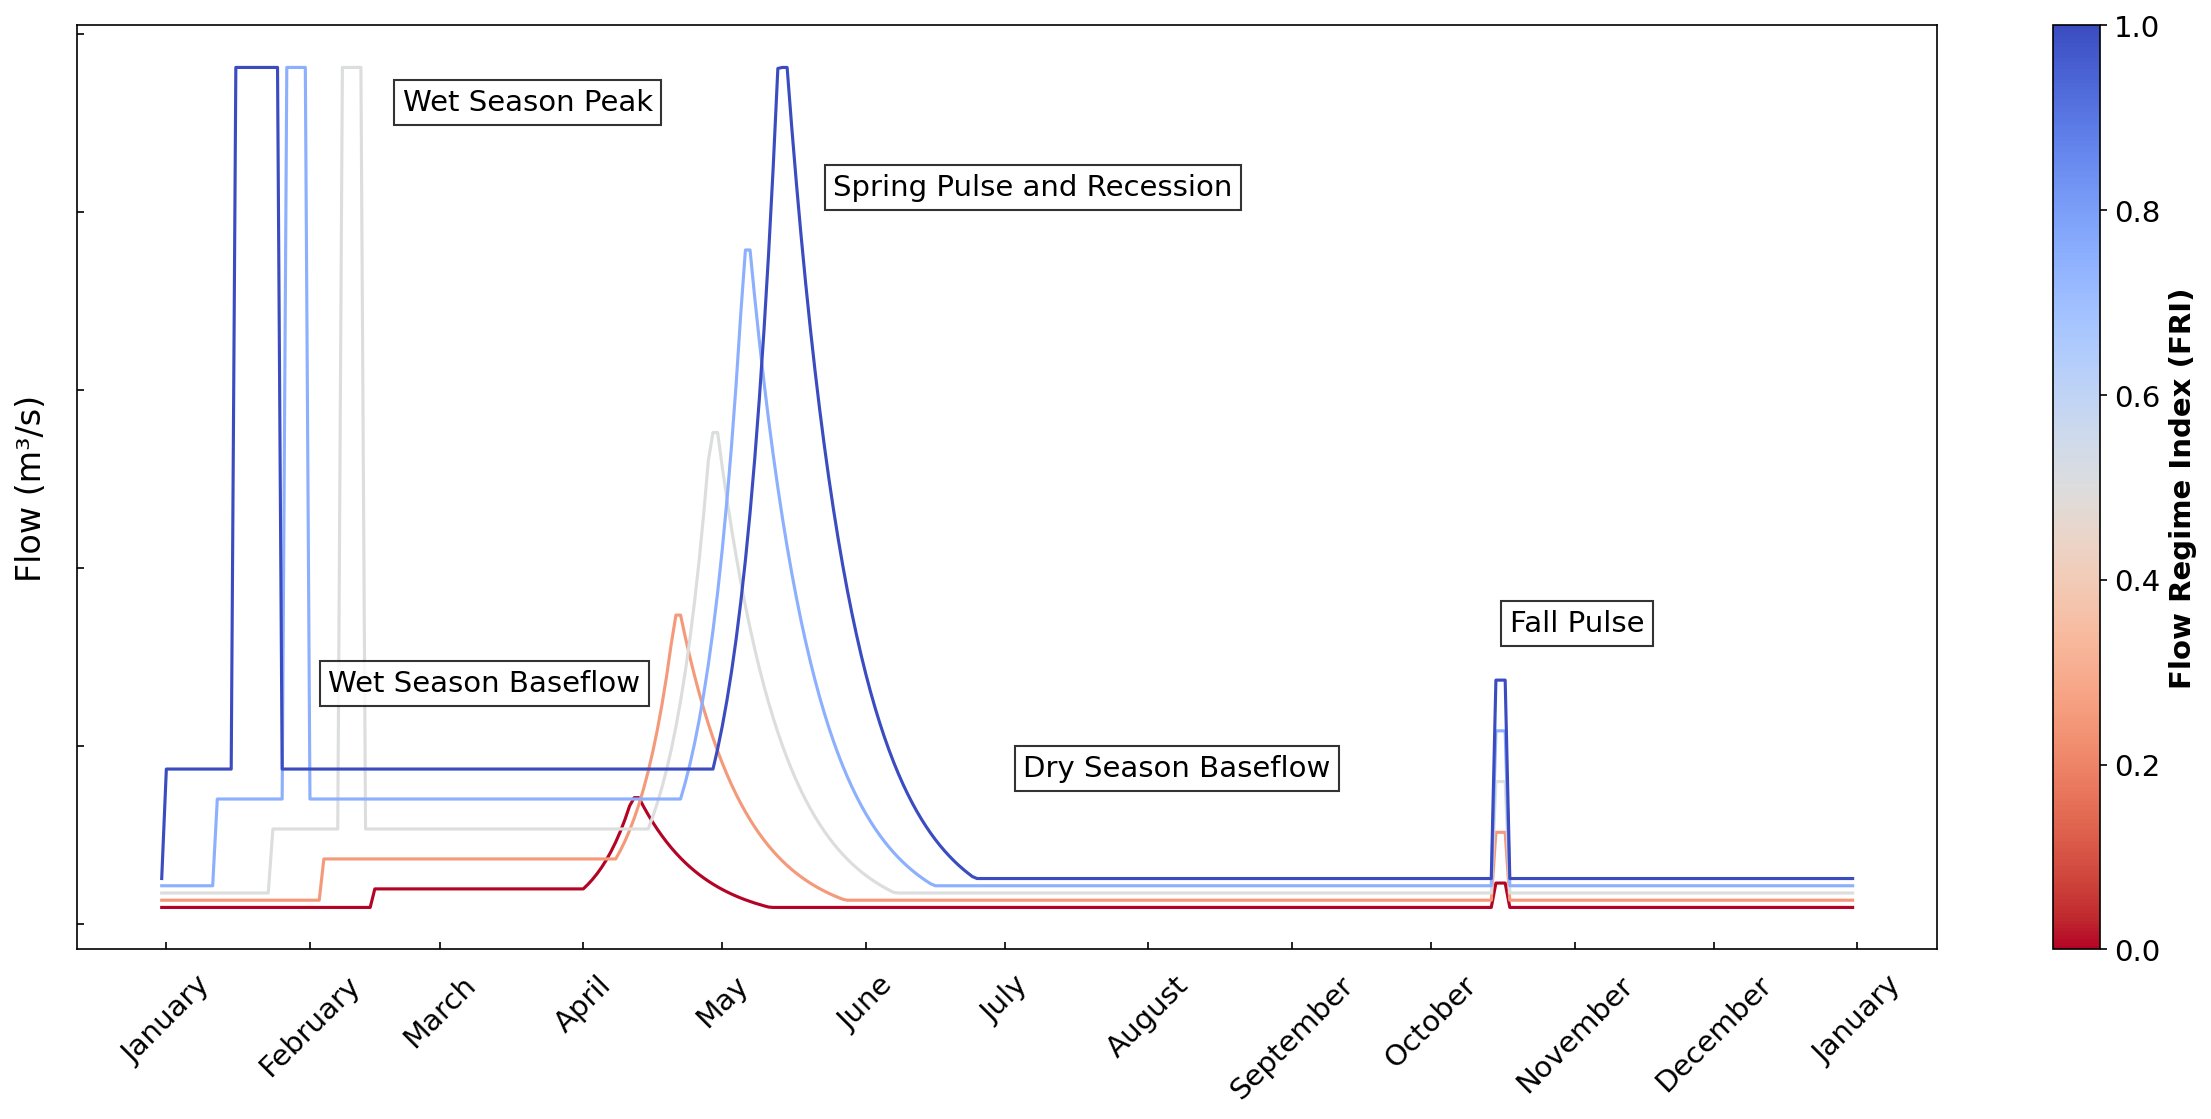

In [10]:
import warnings
warnings.simplefilter(action='ignore', category=FutureWarning)

import numpy as np
import matplotlib.pyplot as plt
import matplotlib.dates as mdates
import datetime as dt
from ffmPerformanceFunctions import inv_performance_Q_WetBFL_cfs,inv_performance_Q_SP_cfs,inv_performance_Q_DS_cfs,inv_performance_Q_FA_cfs 
from FFM_GeneralFunctions import getDailyFlowPeriodDF, dateToWY
import pandas as pd
HIGHLIGHTSCHEDULE=False


df2=pd.DataFrame()

n=5
color_arr = plt.cm.coolwarm_r(np.linspace(0,1,n))
z_arr = np.linspace(10,90,n)

dt_wsp = pd.to_datetime('2021-02-21')
dt_wsb = pd.to_datetime('2021-02-05')
dt_spp = pd.to_datetime('2021-05-25')
dt_spr = pd.to_datetime('2021-06-24')
dt_sbf = pd.to_datetime('2021-07-15')
dt_fp = pd.to_datetime('2021-10-18')

fig, ax = plt.subplots(figsize=(20,8),dpi=150)

for i in range(n):
    z = z_arr[i]
    color = color_arr[i]

    if z<34:
        peak_dur = 0
    elif z<50:
        peak_dur = 3
    elif z<75:
        peak_dur = 5
    else:
        peak_dur = 10
    
    Q_WetBFL = inv_performance_Q_WetBFL_cfs(z)
    Q_SP = inv_performance_Q_SP_cfs(z)
    Q_DS = inv_performance_Q_DS_cfs(z)
    Q_FA = inv_performance_Q_FA_cfs(z)

    V_WetPeak = peak_dur * (peak_mag-Q_WetBFL)

    df = getDailyFlowPeriodDF(dt.date(2020,12,31), dt.date(2021,12,31), dateToWY(dt.date(2020,2,15)-dt.timedelta(days=(11.45*i))), dateToWY(dt.date(2020,4,1)+dt.timedelta(days=(i*7))), V_WetPeak,Q_WetBFL, Q_SP, Q_DS, Q_FA)
    df['DailyFlow_cfs'] = cfs_to_cms(df['DailyFlow_cfs'])

    df.plot(color=color, ax=ax)
    df2['FFRI_'+str(z)] = df

if HIGHLIGHTSCHEDULE:
    z=65
    if z<34:
        peak_dur = 0
    elif z<50:
        peak_dur = 3
    elif z<75:
        peak_dur = 5
    else:
        peak_dur = 10

    Q_WetBFL = inv_performance_Q_WetBFL_cfs(z)
    Q_SP = inv_performance_Q_SP_cfs(z)
    Q_DS = inv_performance_Q_DS_cfs(z)
    Q_FA = inv_performance_Q_FA_cfs(z)

    V_WetPeak = peak_dur * (8500-Q_WetBFL)

    df = getDailyFlowPeriodDF(dt.date(2020,1,31), dt.date(2021,1,31), dateToWY(dt.date(2020,2,1)), dateToWY(dt.date(2020,5,1)), V_WetPeak,Q_WetBFL, Q_SP, Q_DS, Q_FA)
    df.plot(color='#70AD47', linewidth=3.2, ax=ax, label = 'Flow Schedule with FFRI 60')

ax.get_legend().remove()
ax.xaxis.set_major_locator(mdates.MonthLocator())
ax.xaxis.set_major_formatter(mdates.DateFormatter("%B"))
ax.xaxis.set_minor_formatter(mdates.DateFormatter("%B"))
_ = plt.xticks(rotation=45)
sm = plt.cm.ScalarMappable(cmap=plt.cm.coolwarm_r, norm=plt.Normalize(vmin=0, vmax=1))

cbar = fig.colorbar(sm, label='Flow Regime Index (FRI)')
ax.set_ylabel('Flow (m\u00b3/s)',fontsize=16)
cbar.set_label(label='Flow Regime Index (FRI)', size=14, weight='bold')
cbar.ax.tick_params(labelsize=14)

ax.tick_params(axis='both',labelsize=14,direction='in',top=False,right=False, pad = 10)
#ax.grid('on')
ax.text(dt_spp,0.85*cfs_to_cms(Q_SP),'Spring Pulse and Recession',fontsize=14,
	bbox=dict(facecolor='w', edgecolor='k',alpha=0.8))
ax.text(dt_sbf-dt.timedelta(days=10),0.95*cfs_to_cms(Q_WetBFL),'Dry Season Baseflow',fontsize=14,
	bbox=dict(facecolor='w', edgecolor='k',alpha=0.8))
ax.text(dt_fp,1.2*cfs_to_cms(Q_FA),'Fall Pulse',fontsize=14,
	bbox=dict(facecolor='w', edgecolor='k',alpha=0.8))
ax.text(dt_wsb,1.5*cfs_to_cms(Q_WetBFL),'Wet Season Baseflow',fontsize=14,
	bbox=dict(facecolor='w', edgecolor='k',alpha=0.8))
ax.text(dt_wsp,0.95*cfs_to_cms(Q_SP),'Wet Season Peak',fontsize=14,
	bbox=dict(facecolor='w', edgecolor='k',alpha=0.8))
ax.set_yticklabels([])

#fig.savefig('FFR_range.png')


#df2.to_csv('testFFRI_annualhydrographs_many.csv')